In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [1]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


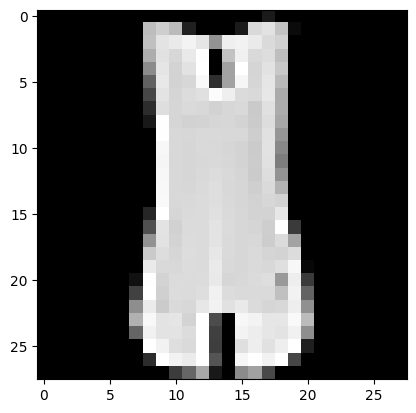

In [6]:
import matplotlib.pyplot as plt

plt.imshow(X_train[4], cmap="gray")
plt.show()

In [7]:
print(y_train[0])

9


In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [11]:
import tensorflow as tf
model = tf.keras.Sequential([

    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')

])

In [12]:
model.compile(

optimizer='adam',

loss='sparse_categorical_crossentropy',

metrics=['accuracy']

)

In [13]:
history = model.fit(

X_train,

y_train,

epochs=10,

validation_split=0.2

)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8160 - loss: 0.5218 - val_accuracy: 0.8533 - val_loss: 0.4175
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8592 - loss: 0.3902 - val_accuracy: 0.8654 - val_loss: 0.3669
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8732 - loss: 0.3487 - val_accuracy: 0.8716 - val_loss: 0.3496
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8817 - loss: 0.3233 - val_accuracy: 0.8753 - val_loss: 0.3480
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8880 - loss: 0.3035 - val_accuracy: 0.8857 - val_loss: 0.3174
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8935 - loss: 0.2887 - val_accuracy: 0.8798 - val_loss: 0.3281
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8992 - loss: 0.2724 - val_accuracy: 0.8811 - val_loss: 0.3280
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9031 - loss: 0.2630 - 

In [14]:
test_loss, test_acc = model.evaluate(X_test,y_test)

print(test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8748 - loss: 0.3568
0.8748000264167786


In [15]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [16]:
import numpy as np

predicted = np.argmax(predictions[0])

actual = y_test[0]

print(predicted)
print(actual)

9
9


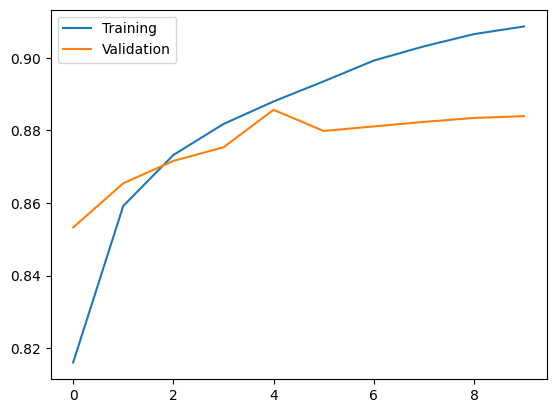

In [23]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.legend(['Training','Validation'])
plt.savefig("Accuracy and Validation.png", dpi=300, bbox_inches='tight')

plt.show()

In [20]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

In [21]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


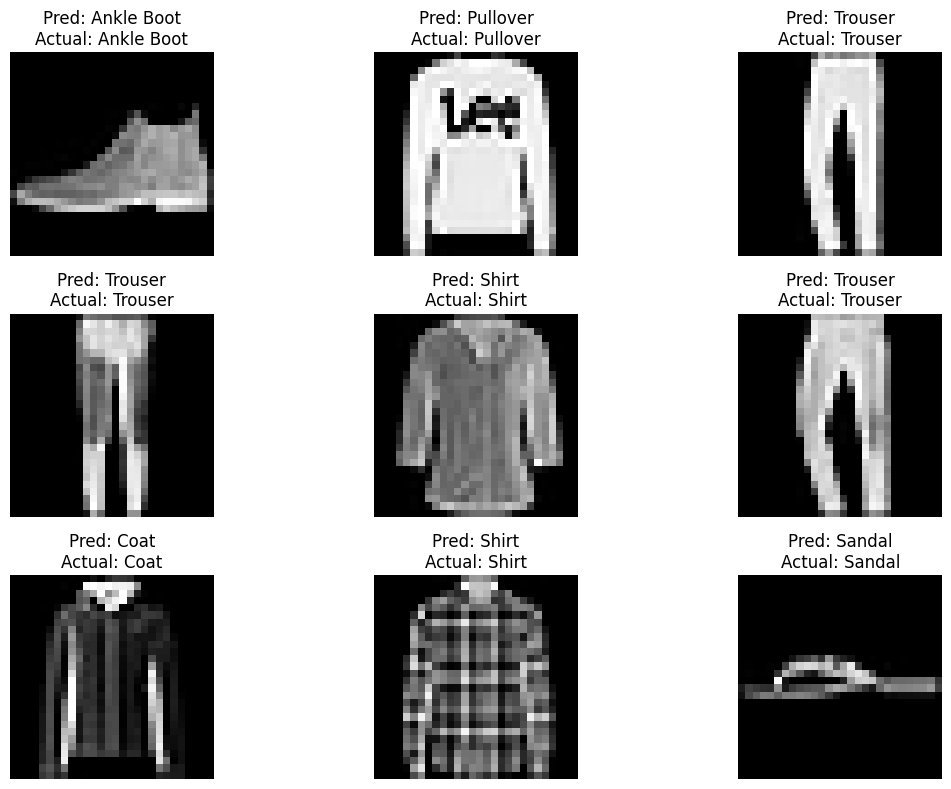

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(X_test[i], cmap="gray")
    plt.axis("off")

    predicted_label = np.argmax(predictions[i])
    actual_label = y_test[i]

    plt.title(
        f"Pred: {class_names[predicted_label]}\n"
        f"Actual: {class_names[actual_label]}"
    )
plt.savefig("Comparison.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()